# Random Forest Regresija — Predikcija Cena Automobila

Random Forest je ansambl (skup) stabala odlucivanja. Svako stablo se trenira na razlicitom podskupu podataka i featura, a finalna predikcija je **prosjek svih stabala**. Ovo ga cini mnogo mocnijim od jednog stabla i otpornijim na overfitting.

Ovaj notebook sadrzi kompletan pipeline:
1. Ucitavanje procesiranog dataseta
2. Encoding kategorickih varijabli (isti kao Ridge)
3. Train/Test split (80/20, random_state=42)
4. Baseline Random Forest model (default parametri)
5. Hyperparameter tuning (GridSearchCV)
6. Feature Importance analiza (Top 10)
7. Finalna evaluacija sa vizualizacijama
8. Poredjenje sa Ridge modelom
9. Cuvanje modela

> **KLJUCNA RAZLIKA U ODNOSU NA RIDGE:** Random Forest **NE zahteva skaliranje** featura! Stabla odlucivanja rade sa pragovima (npr. "ako mileage > 100000 idi levo"), pa im je svejedno da li je skala 0-1 ili 0-500000.

## Korak 1: Importi i Ucitavanje Dataseta

Svaki notebook mora biti **samostalan** — moze se pokrenuti nezavisno. Zato ponovo ucitavamo podatke i radimo encoding.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os
import time
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

BASE_DIR = Path.cwd()
PROCESSED_DIR = BASE_DIR.parent / "DataSet" / "processed"
PROCESSED_DATA_PATH = PROCESSED_DIR / "procesirani_podaci.csv"
df = pd.read_csv(PROCESSED_DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"Kolone: {list(df.columns)}")
df.head()

Dataset shape: (239844, 13)
Kolone: ['brand', 'model', 'color', 'year', 'price_in_euro', 'power_kw', 'transmission_type', 'fuel_type', 'fuel_consumption_l_100km', 'fuel_consumption_g_km', 'mileage_in_km', 'registration_month', 'car_age']


,brand,model,color,year,price_in_euro,power_kw,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,registration_month,car_age
0,alfa-romeo,alfa romeo gtv,red,1995.0,1300.0,148.0,manual,petrol,10.9,260.0,160500.0,10.0,31.0
1,alfa-romeo,alfa romeo 164,black,1995.0,24900.0,191.0,manual,petrol,5.7,135.0,190000.0,2.0,31.0
2,alfa-romeo,alfa romeo spider,black,1995.0,4900.0,110.0,manual,petrol,9.5,225.0,189500.0,7.0,31.0
3,alfa-romeo,alfa romeo 164,red,1996.0,17950.0,132.0,manual,petrol,7.2,135.0,96127.0,11.0,30.0
4,alfa-romeo,alfa romeo spider,red,1996.0,7900.0,110.0,manual,petrol,9.5,225.0,47307.0,4.0,30.0


### Brzi pregled dataseta

In [8]:
print("TIPOVI PODATAKA")
print(df.dtypes)

print("NEDOSTAJUCE VREDNOSTI")
print(df.isnull().sum())

print("OSNOVNA STATISTIKA")
df.describe().round(2)

TIPOVI PODATAKA
brand                           str
model                           str
color                           str
year                        float64
price_in_euro               float64
power_kw                    float64
transmission_type               str
fuel_type                       str
fuel_consumption_l_100km    float64
fuel_consumption_g_km       float64
mileage_in_km               float64
registration_month          float64
car_age                     float64
dtype: object
NEDOSTAJUCE VREDNOSTI
brand                       0
model                       0
color                       0
year                        0
price_in_euro               0
power_kw                    0
transmission_type           0
fuel_type                   0
fuel_consumption_l_100km    0
fuel_consumption_g_km       0
mileage_in_km               0
registration_month          0
car_age                     0
dtype: int64
OSNOVNA STATISTIKA


,year,price_in_euro,power_kw,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,registration_month,car_age
count,239844.00,239844.00,239844.00,239844.00,239844.00,239844.00,239844.00,239844.00
mean,2016.12,24936.46,125.80,6.02,141.25,87019.75,6.30,9.88
std,5.45,25141.76,69.73,1.80,55.37,75092.81,3.38,5.45
min,1995.00,500.00,25.00,0.50,0.00,0.00,1.00,3.00
25%,2013.00,11900.00,84.00,5.00,119.00,27408.75,3.00,6.00
50%,2018.00,19500.00,110.00,5.70,135.00,69978.00,6.00,8.00
75%,2020.00,29850.00,140.00,6.60,157.00,129000.00,9.00,13.00
max,2023.00,300000.00,596.00,30.00,2018.00,500000.00,12.00,31.00


## Korak 2: Encoding Kategorickih Varijabli + Train/Test Split

Encoding je **identican** kao u Ridge notebooku:
- **Target Encoding** za `brand` (47 kategorija) i `model` (1288 kategorija)
- **One-Hot Encoding** za `transmission_type`, `fuel_type`, `color`

> **NAPOMENA O DATA LEAKAGE:** Target Encoding racunamo na celom datasetu pre splita. Studentski projekat -> prihvatljivo, ali idealno bi se racunao SAMO na train setu.

> **NAPOMENA 2:** Koristimo **isti `random_state=42`** kao u Ridge notebooku! Ovo garantuje da oba modela rade na **istom train/test splitu**, pa je poredjenje fer.

In [9]:
#ONE-HOT ENCODING za ostale kategorickae
df = pd.get_dummies(df,
                    columns=['transmission_type', 'fuel_type', 'color'],
                    drop_first=True)

# TRAIN/TEST SPLIT (pre Target Encodinga!) - da bi se izbegao data leakage
X = df.drop('price_in_euro', axis=1)
y = df['price_in_euro']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#TARGET ENCODING za brand i model (samo na train setu)
train_with_target = X_train.join(y_train)

brand_means = train_with_target.groupby('brand')['price_in_euro'].mean()
X_train['brand_encoded'] = X_train['brand'].map(brand_means)
X_test['brand_encoded'] = X_test['brand'].map(brand_means).fillna(y_train.mean())

model_means = train_with_target.groupby('model')['price_in_euro'].mean()
X_train['model_encoded'] = X_train['model'].map(model_means)
X_test['model_encoded'] = X_test['model'].map(model_means).fillna(y_train.mean())

# Izbaci originalne tekstualne kolone
X_train.drop(['brand', 'model'], axis=1, inplace=True)
X_test.drop(['brand', 'model'], axis=1, inplace=True)

print(f"Shape nakon encodinga: {X_train.shape}")

print(f"\nX_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

# NEMA SKALIRANJA — Random Forest ga ne treba!
print("\nSkaliranje: PRESKOCENO (RF ne zahteva skaliranje)")

Shape nakon encodinga: (191875, 30)

X_train: (191875, 30)
X_test:  (47969, 30)

Skaliranje: PRESKOCENO (RF ne zahteva skaliranje)


> **Zasto `.fillna(y_train.mean())`?** Neki brendovi ili modeli mogu postojati u test setu, a da ih nema u train setu. Posto target encoding racunamo samo na train setu, `map()` vraca NaN za nepoznate kategorije. `.fillna(y_train.mean())` tim nepoznatim kategorijama dodeljuje prosecnu cenu iz train seta — najneutralniju mogucnu pretpostavku. Sa 47 brendova ovo se verovatno nece desiti, ali sa 1288 modela sigurno ce neki retki modeli zavrsiti samo u test setu, pa je `fillna` tu kao zastita od NaN vrednosti.

## Korak 3: Baseline Random Forest (Default Parametri)

Treniramo sa 100 stabala (default). Cak i sa default parametrima, Random Forest bi trebao **znacajno nadmasiti Ridge regresiju**.

> **ZASTO `n_jobs=-1`?** Random Forest je paralelizabilan — svako stablo se moze trenirati nezavisno. `n_jobs=-1` znaci "koristi sve dostupne CPU jezgre", sto drasticno ubrzava treniranje.

> **TRAJANJE:** Sa 240k redova i 100 stabala, treniranje moze trajati 1-3 minuta.

In [10]:

start_time = time.time()

rf_baseline = RandomForestRegressor(
    n_estimators=100,   # 100 stabala
    random_state=42,
    n_jobs=-1           # sva CPU jezgra
)

rf_baseline.fit(X_train, y_train)
baseline_time = time.time() - start_time

# Predikcija
y_pred_rf_base = rf_baseline.predict(X_test)

# Metrike
mae_b = mean_absolute_error(y_test, y_pred_rf_base)
rmse_b = np.sqrt(mean_squared_error(y_test, y_pred_rf_base))
r2_b = r2_score(y_test, y_pred_rf_base)

print("BASELINE RANDOM FOREST (default)")
print(f"MAE:  {mae_b:,.2f} EUR")
print(f"RMSE: {rmse_b:,.2f} EUR")
print(f"R2:   {r2_b:.4f}")
print(f"\nVreme treniranja: {baseline_time:.1f} sekundi")

BASELINE RANDOM FOREST (default)
MAE:  3,087.44 EUR
RMSE: 7,030.13 EUR
R2:   0.9229

Vreme treniranja: 38.1 sekundi


## Korak 4: Hyperparameter Tuning (GridSearchCV)

Tri najvaznija parametra za tuning:
- **`n_estimators`** — broj stabala u sumi. Vise stabala = bolje, ali sporije.
- **`max_depth`** — maksimalna dubina svakog stabla. Ogranicava kompleksnost i sprjecava overfitting. `None` = neogranicena dubina.
- **`min_samples_split`** — minimalni broj uzoraka potrebnih za podelu cvora. Veci broj = konzervativniji model.

> **ZASTO `cv=3` a ne `cv=5`?** RF je spor za treniranje na velikom datasetu. Sa 36 kombinacija parametara i 3-fold CV, to je 108 treniranja modela. Sa `cv=5` bi bilo 180 treniranja i trajalo bi predugo. 3-fold je dobar kompromis.

> **TRAJANJE:** Moze trajati **15-40 minuta** u zavisnosti od masine!

In [11]:
# Celija 4: GridSearchCV za Random Forest

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [15, 20, 30, None],
    'min_samples_split': [2, 5, 10]
}

# 3 x 4 x 3 = 36 kombinacija x 3 folda = 108 treniranja
print(f"Ukupno kombinacija: {3*4*3}")
print(f"Ukupno treniranja (x3 folda): {3*4*3*3}")
print("Ovo moze trajati 15-40 minuta...\n")

start_time = time.time()

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=3,               # 3-fold (brze od 5-fold)
    scoring='r2',
    return_train_score=True,
    verbose=2,           # prikazi progres
    n_jobs=1             # RF vec koristi n_jobs=-1
)

grid_rf.fit(X_train, y_train)
tuning_time = time.time() - start_time

print(f"\nVreme tuninga: {tuning_time/60:.1f} minuta")
print(f"Najbolji parametri: {grid_rf.best_params_}")
print(f"Najbolji CV R2: {grid_rf.best_score_:.4f}")

best_rf = grid_rf.best_estimator_


Ukupno kombinacija: 36
Ukupno treniranja (x3 folda): 108
Ovo moze trajati 15-40 minuta...

Fitting 3 folds for each of 36 candidates, totalling 108 fits
[CV] END max_depth=15, min_samples_split=2, n_estimators=100; total time=  14.7s
[CV] END max_depth=15, min_samples_split=2, n_estimators=100; total time=  14.6s
[CV] END max_depth=15, min_samples_split=2, n_estimators=100; total time=  14.4s
[CV] END max_depth=15, min_samples_split=2, n_estimators=200; total time=  28.3s
[CV] END max_depth=15, min_samples_split=2, n_estimators=200; total time=  27.7s
[CV] END max_depth=15, min_samples_split=2, n_estimators=200; total time=  27.9s
[CV] END max_depth=15, min_samples_split=2, n_estimators=300; total time=  41.4s
[CV] END max_depth=15, min_samples_split=2, n_estimators=300; total time=  43.0s
[CV] END max_depth=15, min_samples_split=2, n_estimators=300; total time=  41.0s
[CV] END max_depth=15, min_samples_split=5, n_estimators=100; total time=  14.3s
[CV] END max_depth=15, min_samples_sp

In [28]:
os.makedirs('../models', exist_ok=True)
joblib.dump(best_rf, '../models/rf_model.pkl')
joblib.dump(grid_rf, '../models/rf_grid_search.pkl')
print("Model sacuvan! Ako notebook pukne, ucitaj sa joblib.load()")

Model sacuvan! Ako notebook pukne, ucitaj sa joblib.load()


### Alternativa: RandomizedSearchCV (ako je GridSearchCV prespor)

Ako GridSearchCV traje predugo, mozes koristiti `RandomizedSearchCV` — ne testira SVE kombinacije, vec nasumicno uzorkuje `n_iter` kombinacija. Odkomentiraj celiju ispod ako ti treba.

In [12]:
# Celija 4b: ALTERNATIVA — RandomizedSearchCV (odkomentiraj ako treba)
# 
# param_dist = {
#     'n_estimators': [100, 200, 300, 500],
#     'max_depth': [10, 15, 20, 30, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }
# 
# random_rf = RandomizedSearchCV(
#     RandomForestRegressor(random_state=42, n_jobs=-1),
#     param_dist,
#     n_iter=15,           # testira samo 15 kombinacija
#     cv=3,
#     scoring='r2',
#     verbose=2,
#     random_state=42,
#     n_jobs=1
# )
# 
# random_rf.fit(X_train, y_train)
# print(f"Najbolji parametri: {random_rf.best_params_}")
# print(f"Najbolji CV R2: {random_rf.best_score_:.4f}")
# best_rf = random_rf.best_estimator_

### Vizualizacija: Uticaj Hyperparametara na R2

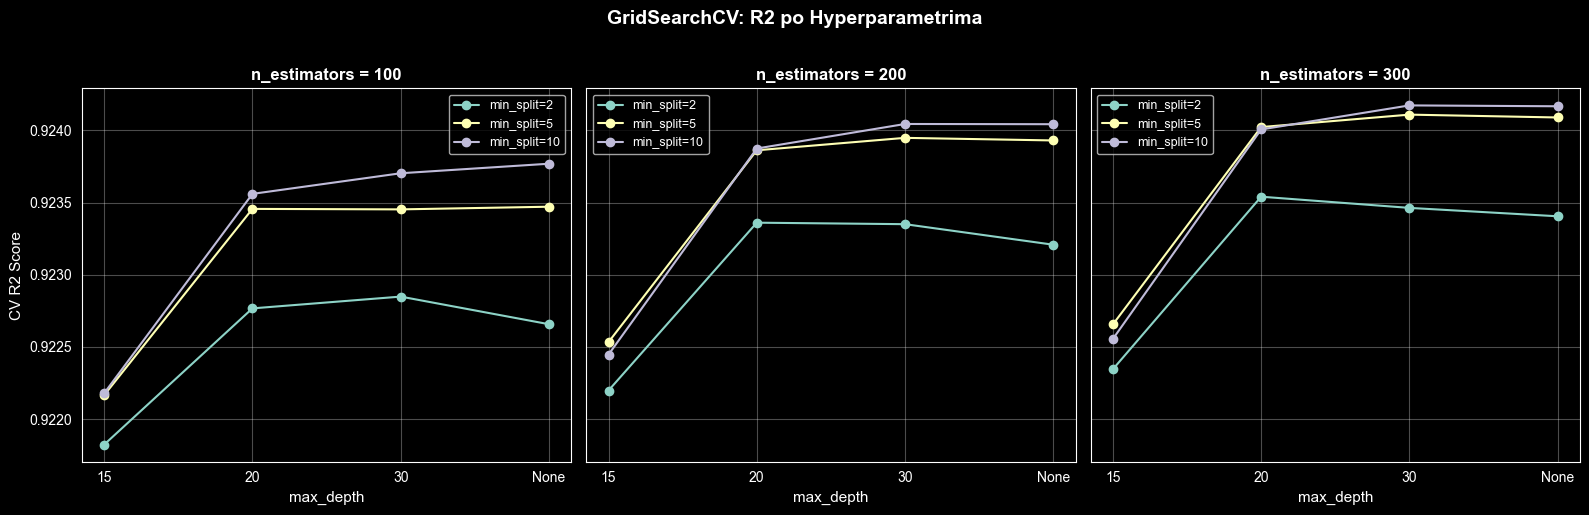

Top 5 kombinacija parametara:
 n_estimators max_depth  min_samples_split  CV R2 (test)      Std  CV R2 (train)
          300        30                 10      0.924173 0.000429       0.972143
          300      None                 10      0.924167 0.000417       0.972148
          300        30                  5      0.924109 0.000460       0.982081
          300      None                  5      0.924089 0.000466       0.982090
          200        30                 10      0.924044 0.000362       0.972086


In [20]:
# Celija 4c: Vizualizacija CV rezultata

cv_results = pd.DataFrame(grid_rf.cv_results_)

# R2 po max_depth za svaku vrednost n_estimators
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for idx, n_est in enumerate([100, 200, 300]):
    ax = axes[idx]
    subset = cv_results[cv_results['param_n_estimators'] == n_est]
    
    for mss in [2, 5, 10]:
        mask = subset['param_min_samples_split'] == mss
        data = subset[mask].sort_values('param_max_depth', key=lambda x: x.fillna(999))
        
        depth_labels = data['param_max_depth'].apply(lambda x: 'None' if x is None else str(x))
        ax.plot(depth_labels, data['mean_test_score'], 'o-', label=f'min_split={mss}', markersize=6)
    
    ax.set_title(f'n_estimators = {n_est}', fontsize=12, fontweight='bold')
    ax.set_xlabel('max_depth', fontsize=11)
    if idx == 0:
        ax.set_ylabel('CV R2 Score', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('GridSearchCV: R2 po Hyperparametrima', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('rf_hyperparameter_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

# Top 5 kombinacija
top5 = cv_results.nlargest(5, 'mean_test_score')[
    ['param_n_estimators', 'param_max_depth', 'param_min_samples_split', 
     'mean_test_score', 'std_test_score', 'mean_train_score']
].reset_index(drop=True)
top5.columns = ['n_estimators', 'max_depth', 'min_samples_split', 'CV R2 (test)', 'Std', 'CV R2 (train)']
print("Top 5 kombinacija parametara:")
print(top5.to_string(index=False))

### Analiza rezultata GridSearchCV

Grafikoni prikazuju kako svaki hyperparametar utice na R2 score modela.

**Uticaj `max_depth` (dubina stabala):**
- `max_depth=15` daje najlosije rezultate u svim kombinacijama — stabla su plitka i ne mogu uhvatiti kompleksnije obrasce u podacima.
- Performanse znacajno rastu sa `max_depth=20`, a nakon toga se stabilizuju. Razlika izmedju `max_depth=30` i `None` (neogranicena dubina) je zanemariva.

**Uticaj `n_estimators` (broj stabala):**
- Vise stabala = bolji i stabilniji rezultati. Grafikon za `n_estimators=300` ima najuze rasipanje linija i najvise R2 vrednosti. Medjutim, poboljsanje od 200 do 300 stabala je minimalno — zakon opadajucih prinosa.

**Uticaj `min_samples_split`:**
- `min_samples_split=10` daje najbolji test R2 (0.9242) sa train R2 od 0.9721 — razlika od ~0.048 ukazuje na kontrolisan overfitting.
- `min_samples_split=5` ima skoro isti test R2 (0.9241), ali train R2 skace na 0.9821 — veci gap znaci vise overfittinga.
- `min_samples_split=2` ima najnizi test R2 i najveci overfitting.

**Zakljucak:** Top 5 kombinacija daje skoro identicne rezultate (R2 izmedju 0.9240 i 0.9242). Model je izabrao `max_depth=30, min_samples_split=10, n_estimators=300` jer daje najbolji balans izmedju performansi i kontrole overfittinga — dovoljno duboka stabla da uhvate obrasce, ali sa restrikcijom na minimalni broj uzoraka po cvoru koja sprecava prekomerno prilagodjavanje train setu.

## Korak 5: Feature Importance — Top 10

Jedna od najvecih prednosti Random Foresta je mogucnost da vidimo koji feature najvise utice na predikciju. Feature importance se racuna na osnovu toga koliko svaki feature u proseku smanjuje "necistocu" (impurity) u cvorovima stabala.

> **Sta ocekivati:** Tipicno ce `model_encoded`, `brand_encoded`, `power_kw`, `car_age` i `mileage_in_km` biti na vrhu. Ovo je intuitivno — model i marka, snaga motora, starost i kilometraza su glavni faktori cene polovnih automobila.

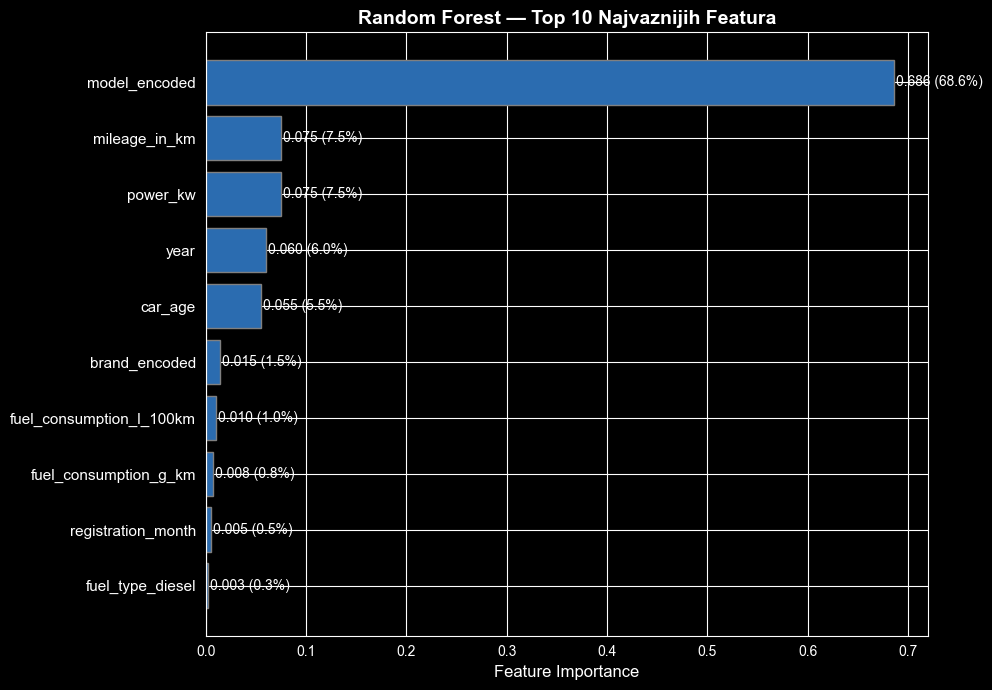


Svih 10 Feature Importances:
  model_encoded                       0.6856 (68.6%)
  mileage_in_km                       0.0749 (7.5%)
  power_kw                            0.0745 (7.5%)
  year                                0.0601 (6.0%)
  car_age                             0.0547 (5.5%)
  brand_encoded                       0.0146 (1.5%)
  fuel_consumption_l_100km            0.0102 (1.0%)
  fuel_consumption_g_km               0.0076 (0.8%)
  registration_month                  0.0048 (0.5%)
  fuel_type_diesel                    0.0025 (0.3%)

Ovih top 10 featura objasnjava 98.9% ukupne vaznosti.


In [21]:
# Celija 5: Feature Importance

importances = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Top 10
top10 = importances.head(10)

plt.figure(figsize=(10, 7))
bars = plt.barh(range(len(top10)), top10.values,
                color='#2b6cb0', edgecolor='gray')
plt.yticks(range(len(top10)), top10.index, fontsize=11)
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Random Forest — Top 10 Najvaznijih Featura',
          fontsize=14, fontweight='bold')

# Dodaj procente na barove
for i, (val, name) in enumerate(zip(top10.values, top10.index)):
    plt.text(val + 0.002, i, f'{val:.3f} ({val*100:.1f}%)',
             va='center', fontsize=10)

plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSvih 10 Feature Importances:")
for name, imp in top10.items():
    print(f"  {name:35s} {imp:.4f} ({imp*100:.1f}%)")

print(f"\nOvih top 10 featura objasnjava {top10.sum()*100:.1f}% ukupne vaznosti.")

## Korak 6: Finalna Evaluacija + Predicted vs Actual

Evaluiramo tunirani model na test setu. Ocekujemo **znacajno bolje rezultate od Ridge regresije**, posebno za skupe automobile.

In [22]:
# Celija 6: Finalna evaluacija Random Forest

y_pred_rf = best_rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)

print("RANDOM FOREST (tuned)")
print(f"Parametri: {grid_rf.best_params_}")
print(f"MAE:  {mae:,.2f} EUR")
print(f"RMSE: {rmse:,.2f} EUR")
print(f"R2:   {r2:.4f}")

# Poredjenje sa baseline
print("POREDJENJE: Baseline vs Tuned")
print(f"{'Metrika':<10} {'Baseline':>12} {'Tuned':>12} {'Razlika':>12}")
print(f"{'MAE':<10} {mae_b:>12,.2f} {mae:>12,.2f} {mae_b - mae:>+12,.2f}")
print(f"{'RMSE':<10} {rmse_b:>12,.2f} {rmse:>12,.2f} {rmse_b - rmse:>+12,.2f}")
print(f"{'R2':<10} {r2_b:>12.4f} {r2:>12.4f} {r2 - r2_b:>+12.4f}")

RANDOM FOREST (tuned)
Parametri: {'max_depth': 30, 'min_samples_split': 10, 'n_estimators': 300}
MAE:  3,050.62 EUR
RMSE: 6,979.37 EUR
R2:   0.9240
POREDJENJE: Baseline vs Tuned
Metrika        Baseline        Tuned      Razlika
MAE            3,087.44     3,050.62       +36.81
RMSE           7,030.13     6,979.37       +50.76
R2               0.9229       0.9240      +0.0011


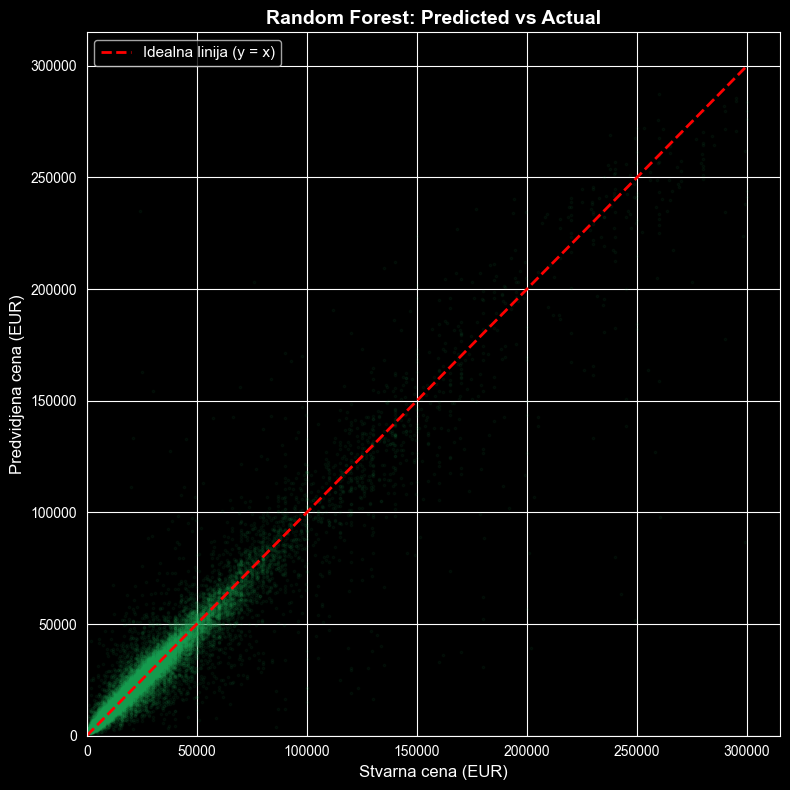

In [23]:
# Celija 6b: Predicted vs Actual scatter plot

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(y_test, y_pred_rf, alpha=0.05, s=3, color='#27ae60')

max_val = max(y_test.max(), y_pred_rf.max())
ax.plot([0, max_val], [0, max_val], 'r--', lw=2,
        label='Idealna linija (y = x)')

ax.set_xlabel('Stvarna cena (EUR)', fontsize=12)
ax.set_ylabel('Predvidjena cena (EUR)', fontsize=12)
ax.set_title('Random Forest: Predicted vs Actual',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim(0, max_val * 1.05)
ax.set_ylim(0, max_val * 1.05)

plt.tight_layout()
plt.savefig('rf_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

### Distribucija Residuala (gresaka)

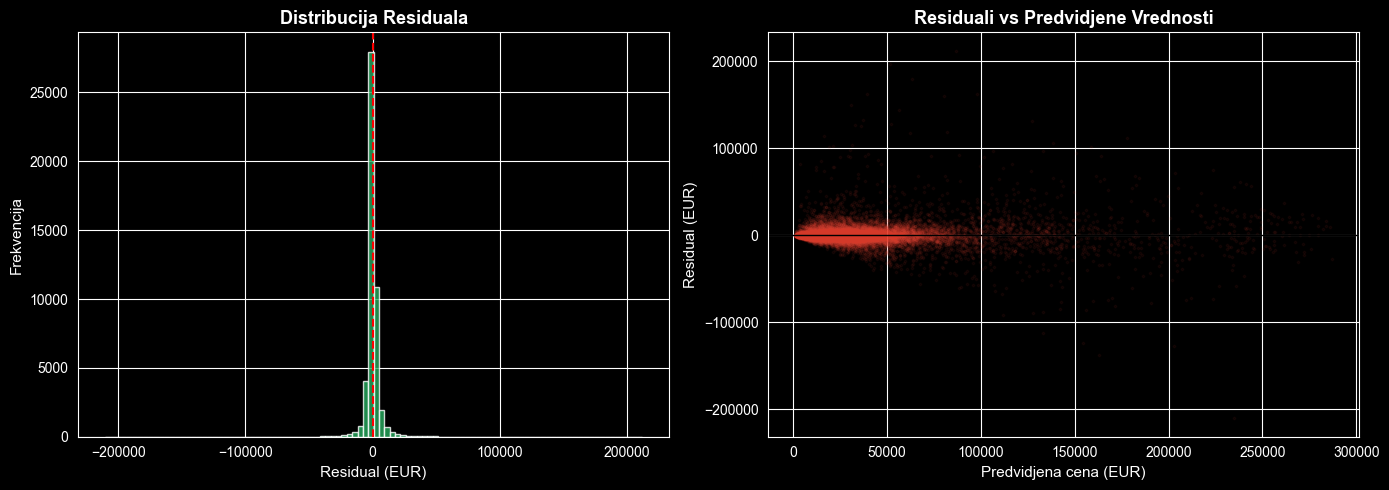

Srednji residual: -18.87 EUR
Std residuala:    6,979.42 EUR


In [24]:
# Celija 6c: Distribucija residuala

residuals = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram residuala
axes[0].hist(residuals, bins=100, color='#27ae60', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0, color='red', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Residual (EUR)', fontsize=11)
axes[0].set_ylabel('Frekvencija', fontsize=11)
axes[0].set_title('Distribucija Residuala', fontsize=13, fontweight='bold')

# Residuals vs Predicted
axes[1].scatter(y_pred_rf, residuals, alpha=0.05, s=3, color='#e74c3c')
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_xlabel('Predvidjena cena (EUR)', fontsize=11)
axes[1].set_ylabel('Residual (EUR)', fontsize=11)
axes[1].set_title('Residuali vs Predvidjene Vrednosti', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('rf_residuali.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Srednji residual: {residuals.mean():,.2f} EUR")
print(f"Std residuala:    {residuals.std():,.2f} EUR")

## Korak 7: Poredjenje sa Ridge Regresijom

Ucitavamo sacuvani Ridge model i poredimo rezultate na **istom test setu** (zahvaljujuci istom `random_state=42`).

> Ako Ridge model nije sacuvan, mozete rucno uneti rezultate iz Ridge notebooka.

In [25]:
# Celija 7: Poredjenje sa Ridge modelom

# Pokusaj ucitati Ridge model
try:
    ridge_model = joblib.load('../models/ridge_model.pkl')
    scaler = joblib.load('../models/scaler.pkl')
    
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test),
        columns=X_test.columns, index=X_test.index
    )
    y_pred_ridge = ridge_model.predict(X_test_scaled)
    
    ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
    ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
    ridge_r2 = r2_score(y_test, y_pred_ridge)
    
    print("Ridge model uspesno ucitan!\n")

except (FileNotFoundError, ValueError) as e:
    # FileNotFoundError: model ne postoji
    # ValueError: razlicit redosled kolona (encoding promenjen)
    print(f"Ridge model nije moguce ucitati: {type(e).__name__}")
    print("Koriste se rucno unete vrednosti iz Ridge notebooka.\n")
    ridge_mae = 5862.07
    ridge_rmse = 10694.82
    ridge_r2 = 0.8215

# Tabela poredjenja
comparison = pd.DataFrame({
    'Model': ['Ridge Regression', 'Random Forest'],
    'MAE (EUR)': [ridge_mae, mae],
    'RMSE (EUR)': [ridge_rmse, rmse],
    'R2': [ridge_r2, r2]
}).round(2)

print("=" * 60)
print("POREDJENJE MODELA")
print("=" * 60)
print(comparison.to_string(index=False))

print(f"\nPoboljsanje RF u odnosu na Ridge:")
print(f"  MAE:  {ridge_mae - mae:+,.2f} EUR ({(ridge_mae - mae)/ridge_mae*100:+.1f}%)")
print(f"  RMSE: {ridge_rmse - rmse:+,.2f} EUR ({(ridge_rmse - rmse)/ridge_rmse*100:+.1f}%)")
print(f"  R2:   {r2 - ridge_r2:+.4f}")

Ridge model nije moguce ucitati: ValueError
Koriste se rucno unete vrednosti iz Ridge notebooka.

POREDJENJE MODELA
           Model  MAE (EUR)  RMSE (EUR)   R2
Ridge Regression    5862.07    10694.82 0.82
   Random Forest    3050.62     6979.37 0.92

Poboljsanje RF u odnosu na Ridge:
  MAE:  +2,811.45 EUR (+48.0%)
  RMSE: +3,715.45 EUR (+34.7%)
  R2:   +0.1025


### Vizuelno poredjenje: Ridge vs Random Forest

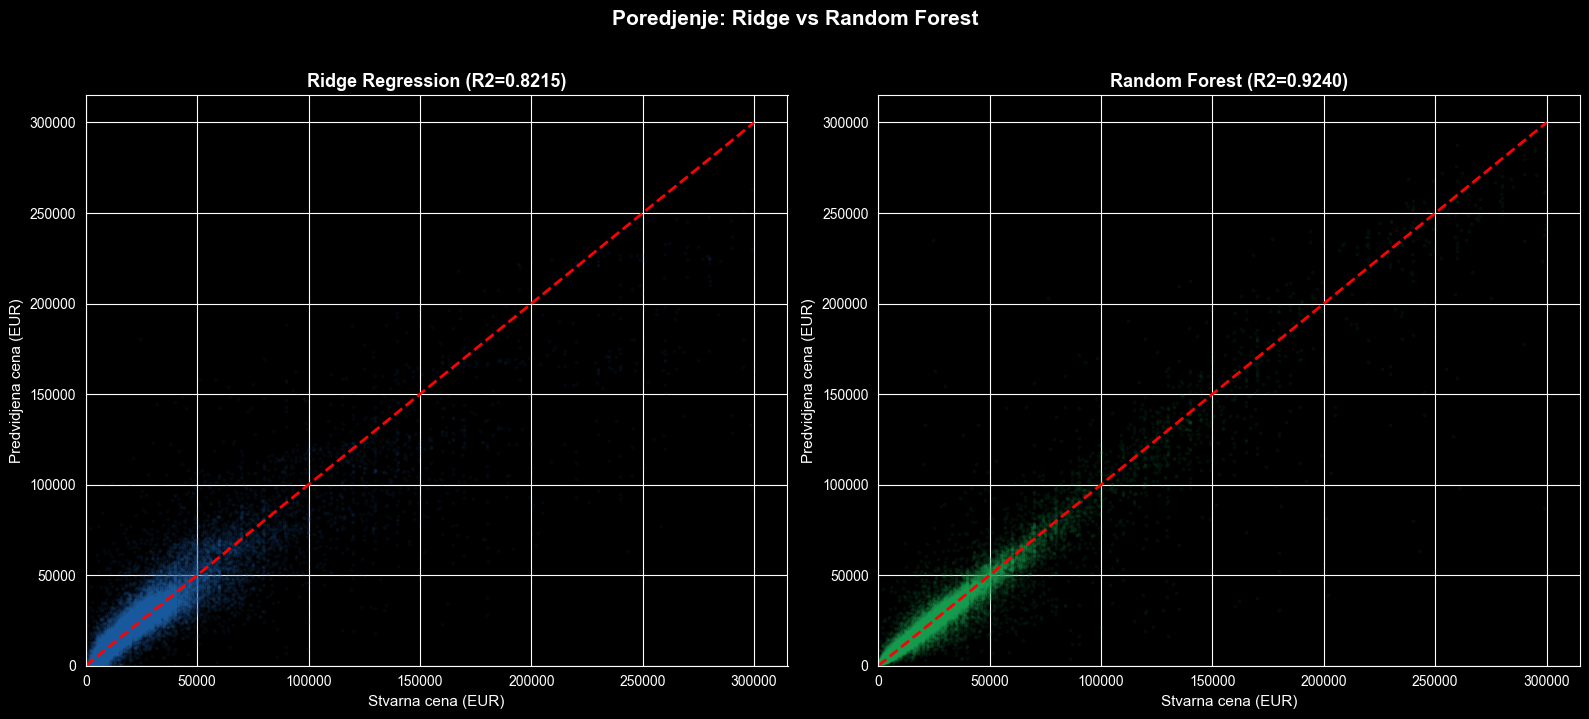

In [29]:
# Celija 7b: Vizuelno poredjenje pred vs actual

try:
    ridge_model = joblib.load('../models/ridge_model.pkl')
    scaler = joblib.load('../models/scaler.pkl')

    # Preuredi kolone da odgovaraju redosledu koji scaler ocekuje
    expected_cols = scaler.feature_names_in_
    X_test_reordered = X_test[expected_cols]

    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test_reordered),
        columns=expected_cols, index=X_test.index
    )
    y_pred_ridge = ridge_model.predict(X_test_scaled)

    # Side-by-side poredjenje
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    max_val = max(y_test.max(), y_pred_rf.max(), y_pred_ridge.max())

    # Ridge
    axes[0].scatter(y_test, y_pred_ridge, alpha=0.05, s=3, color='#2b6cb0')
    axes[0].plot([0, max_val], [0, max_val], 'r--', lw=2)
    axes[0].set_xlabel('Stvarna cena (EUR)', fontsize=11)
    axes[0].set_ylabel('Predvidjena cena (EUR)', fontsize=11)
    axes[0].set_title(f'Ridge Regression (R2={ridge_r2:.4f})', fontsize=13, fontweight='bold')
    axes[0].set_xlim(0, max_val * 1.05)
    axes[0].set_ylim(0, max_val * 1.05)

    # Random Forest
    axes[1].scatter(y_test, y_pred_rf, alpha=0.05, s=3, color='#27ae60')
    axes[1].plot([0, max_val], [0, max_val], 'r--', lw=2)
    axes[1].set_xlabel('Stvarna cena (EUR)', fontsize=11)
    axes[1].set_ylabel('Predvidjena cena (EUR)', fontsize=11)
    axes[1].set_title(f'Random Forest (R2={r2:.4f})', fontsize=13, fontweight='bold')
    axes[1].set_xlim(0, max_val * 1.05)
    axes[1].set_ylim(0, max_val * 1.05)

    plt.suptitle('Poredjenje: Ridge vs Random Forest', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('poredjenje_ridge_vs_rf.png', dpi=150, bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"Greska pri ucitavanju Ridge modela: {e}")
    print("Preskoceno vizuelno poredjenje.")

## Korak 8: Sacuvaj Random Forest Model i Rezultate

In [30]:
# Celija 8: Cuvanje modela i rezultata
# Sacuvaj rezultate
rf_results = {
    'Model': 'Random Forest',
    'Najbolji parametri': grid_rf.best_params_,
    'MAE (EUR)': round(mae, 2),
    'RMSE (EUR)': round(rmse, 2),
    'R2': round(r2, 4)
}

print("Model sacuvan u ../models/rf_model.pkl")
print("\nFinalni rezultati:")
for k, v in rf_results.items():
    print(f"  {k}: {v}")

Model sacuvan u ../models/rf_model.pkl

Finalni rezultati:
  Model: Random Forest
  Najbolji parametri: {'max_depth': 30, 'min_samples_split': 10, 'n_estimators': 300}
  MAE (EUR): 3050.62
  RMSE (EUR): 6979.37
  R2: 0.924


---

## Rezime

| Stavka | Vrednost |
|--------|----------|
| **Model** | Random Forest Regressor (ansambl stabala odlucivanja) |
| **Encoding** | Target Encoding (brand, model) + One-Hot Encoding (transmission, fuel, color) |
| **Skaliranje** | NIJE potrebno za Random Forest |
| **Tuning** | GridSearchCV, 3-fold CV, 36 kombinacija parametara |
| **Evaluacija** | MAE, RMSE, R2 na test setu |

### Kljucne razlike u odnosu na Ridge:
- RF **ne zahteva skaliranje** featura
- RF moze uhvatiti **nelinearne odnose** u podacima
- RF pruza **feature importance** umesto koeficijenata
- RF je **sporiji za treniranje**, ali daje bolje rezultate

Sacuvani fajlovi:
- `rf_model.pkl` — trenirani Random Forest model
- `rf_feature_importance.png` — top 10 najvaznijih featura
- `rf_pred_vs_actual.png` — predicted vs actual scatter
- `rf_hyperparameter_tuning.png` — CV rezultati po hyperparametrima
- `rf_residuali.png` — distribucija gresaka modela
- `poredjenje_ridge_vs_rf.png` — vizuelno poredjenje dva modela